# Лабораторная работа 2. Пакет Matplotlib

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Задание 1 (1 балл)
Сгенерируйте массив нормально распределенных значений размерности 2 из 100 точек (выберите среднее значение μ и среднее квадратическое отклонение σ по своему выбору). Проверьте правило трех сигм: нарисуйте окружность с центром в точке μ с 
таким радиусом, чтобы на нее приходилось 0,99 всех точек, а также окружность радиусом 3 сигмы. Выделите точку μ отдельным цветом.

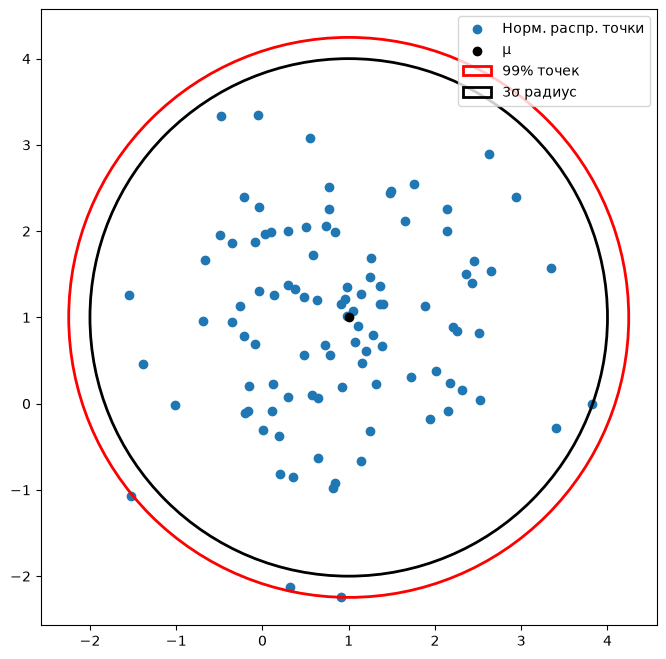

In [45]:
from matplotlib.patches import Circle

mu = 1
sigma = 1
dots_x = np.random.normal(mu, sigma, 100)
dots_y = np.random.normal(mu, sigma, 100)

fig, axes = plt.subplots(figsize=(8, 8))
axes.set_aspect("equal")
axes.scatter(dots_x, dots_y, label="Норм. распр. точки")
axes.scatter(mu, mu, color="black", label="μ")

distances = np.sqrt((dots_x - mu) ** 2 + (dots_y - mu) ** 2)

circle_99 = Circle(
    (mu, mu), np.percentile(distances, 99), color="red", fill=False, linewidth=2,
    label="99% точек"
)

circle_3sigma = Circle(
    (mu, mu), 3 * sigma, color="black", fill=False, linewidth=2, label="3σ радиус"
)

axes.add_patch(circle_99)
axes.add_patch(circle_3sigma)
axes.legend()

### Задание 2 (1 балл)
Используйте вспомогательный график, чтобы нарисовать гистограммы с 10 сегментами для каждого измерения и построить график плотности вдоль гистограммы для данных из первого задания.

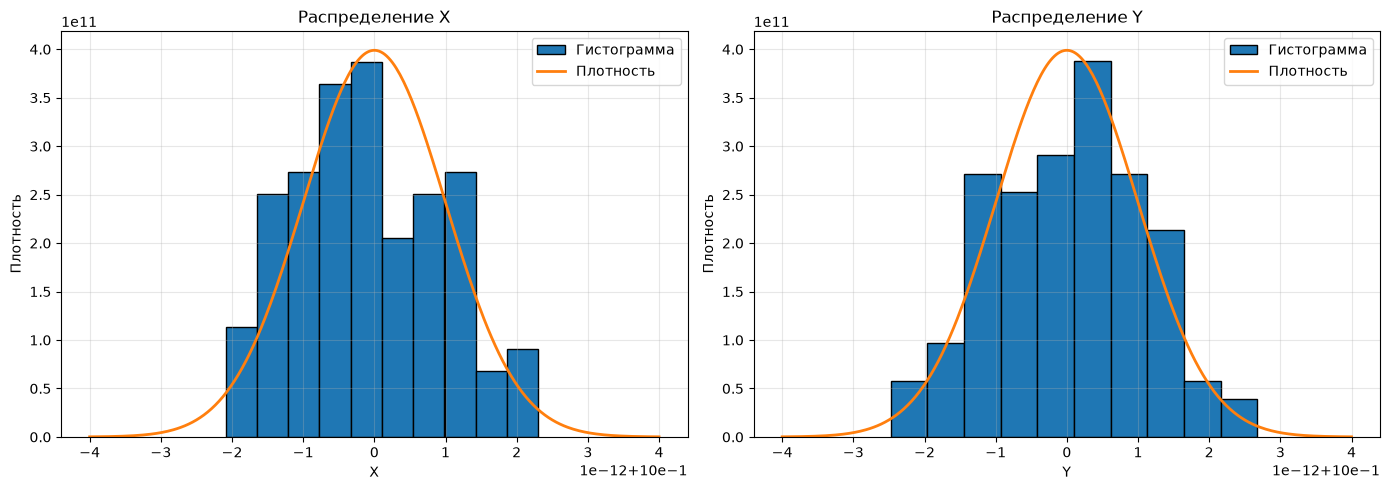

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)

density = (
    1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
)

axes[0].hist(
    dots_x,
    bins=10,
    density=True,
    edgecolor="black",
    label="Гистограмма"
)

axes[0].plot(
    x,
    density,
    linewidth=2,
    label="Плотность"
)

axes[0].set_title("Распределение X")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Плотность")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(
    dots_y,
    bins=10,
    density=True,
    edgecolor="black",
    label="Гистограмма"
)

axes[1].plot(
    x,
    density,
    linewidth=2,
    label="Плотность"
)

axes[1].set_title("Распределение Y")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("Плотность")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3 (2 балла)
Загрузите набор данных "Ирисы Фишера". Создайте тепловую карту с корреляциями между объектами, строки и столбцы которой должны быть подписаны названиями объектов. Важно использовать matplotlib. Прямая корреляция должна отображаться зеленым цветом, обратная — красным, а отсутствие корреляции — белым. Сделайте график достаточно крупным.

Подсказка: используйте plt.xticks, plt.yticks, plt.imshow, plt.colorbar

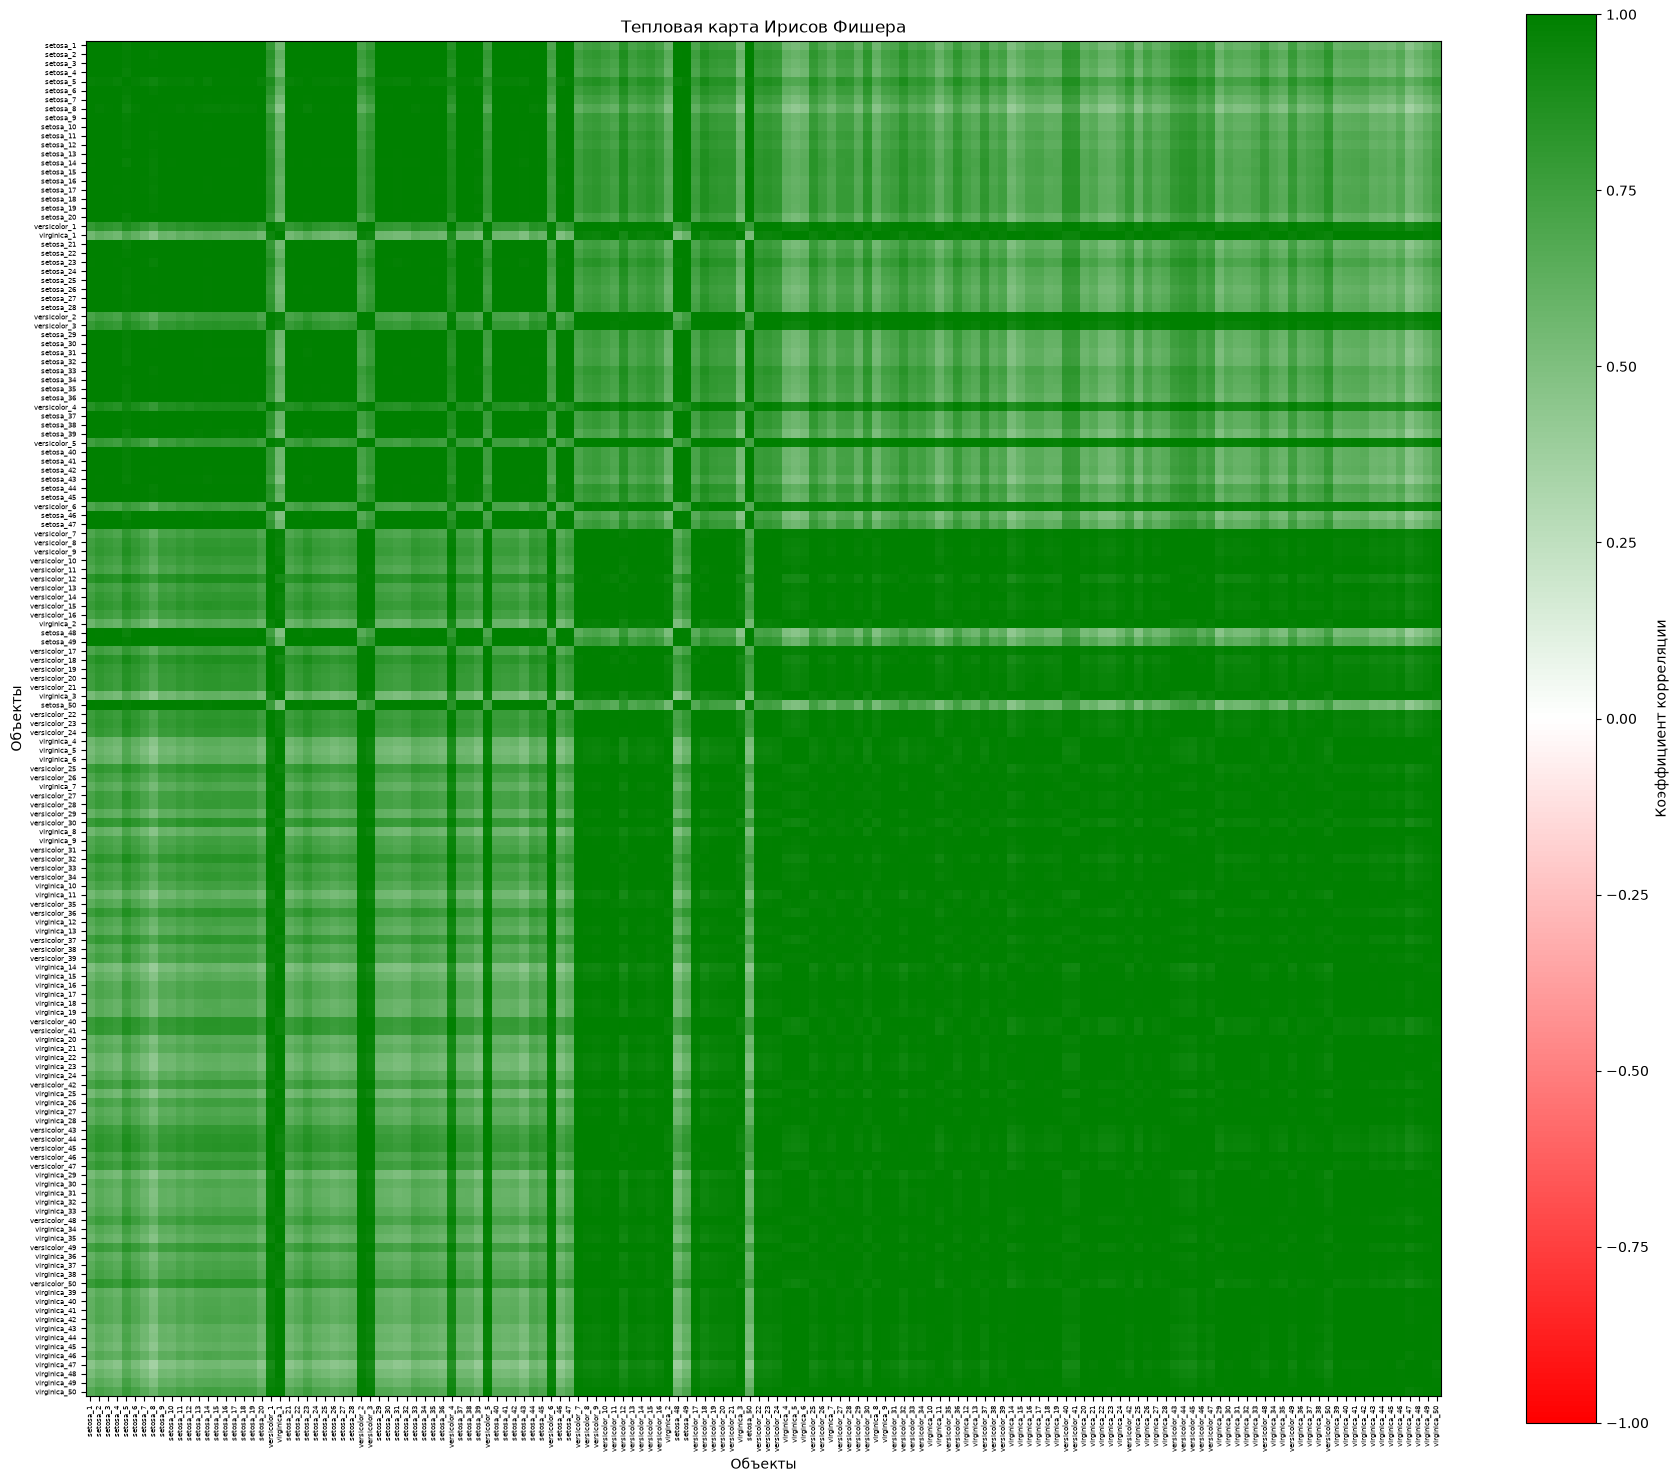

In [ ]:
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

iris = pd.read_csv("iris.csv")

features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
data = iris[features].values

names = []
counters = {}

for species in iris["species"]:
    if species not in counters:
        counters[species] = 1
    else:
        counters[species] += 1

    names.append(f"{species}_{counters[species]}")

correlation = np.corrcoef(data)

cmap = LinearSegmentedColormap.from_list("red_white_green", ["red", "white", "green"])

fig, axes = plt.subplots(figsize=(18, 15))

axes.imshow(correlation, cmap=cmap, vmin=-1, vmax=1, interpolation="nearest")

axes.set_xticks(np.arange(len(names)))
axes.set_xticklabels(names, rotation=90, fontsize=5)

axes.set_yticks(np.arange(len(names)))
axes.set_yticklabels(names, fontsize=5)

fig.colorbar(axes.images[0], ax=axes, label="Коэффициент корреляции")

axes.set_title("Тепловая карта Ирисов Фишера")
axes.set_xlabel("Объекты")
axes.set_ylabel("Объекты")

fig.tight_layout()
plt.show()

### Задание 4
Cоздайте такую же тепловую карту, используя seaborn.heatmap

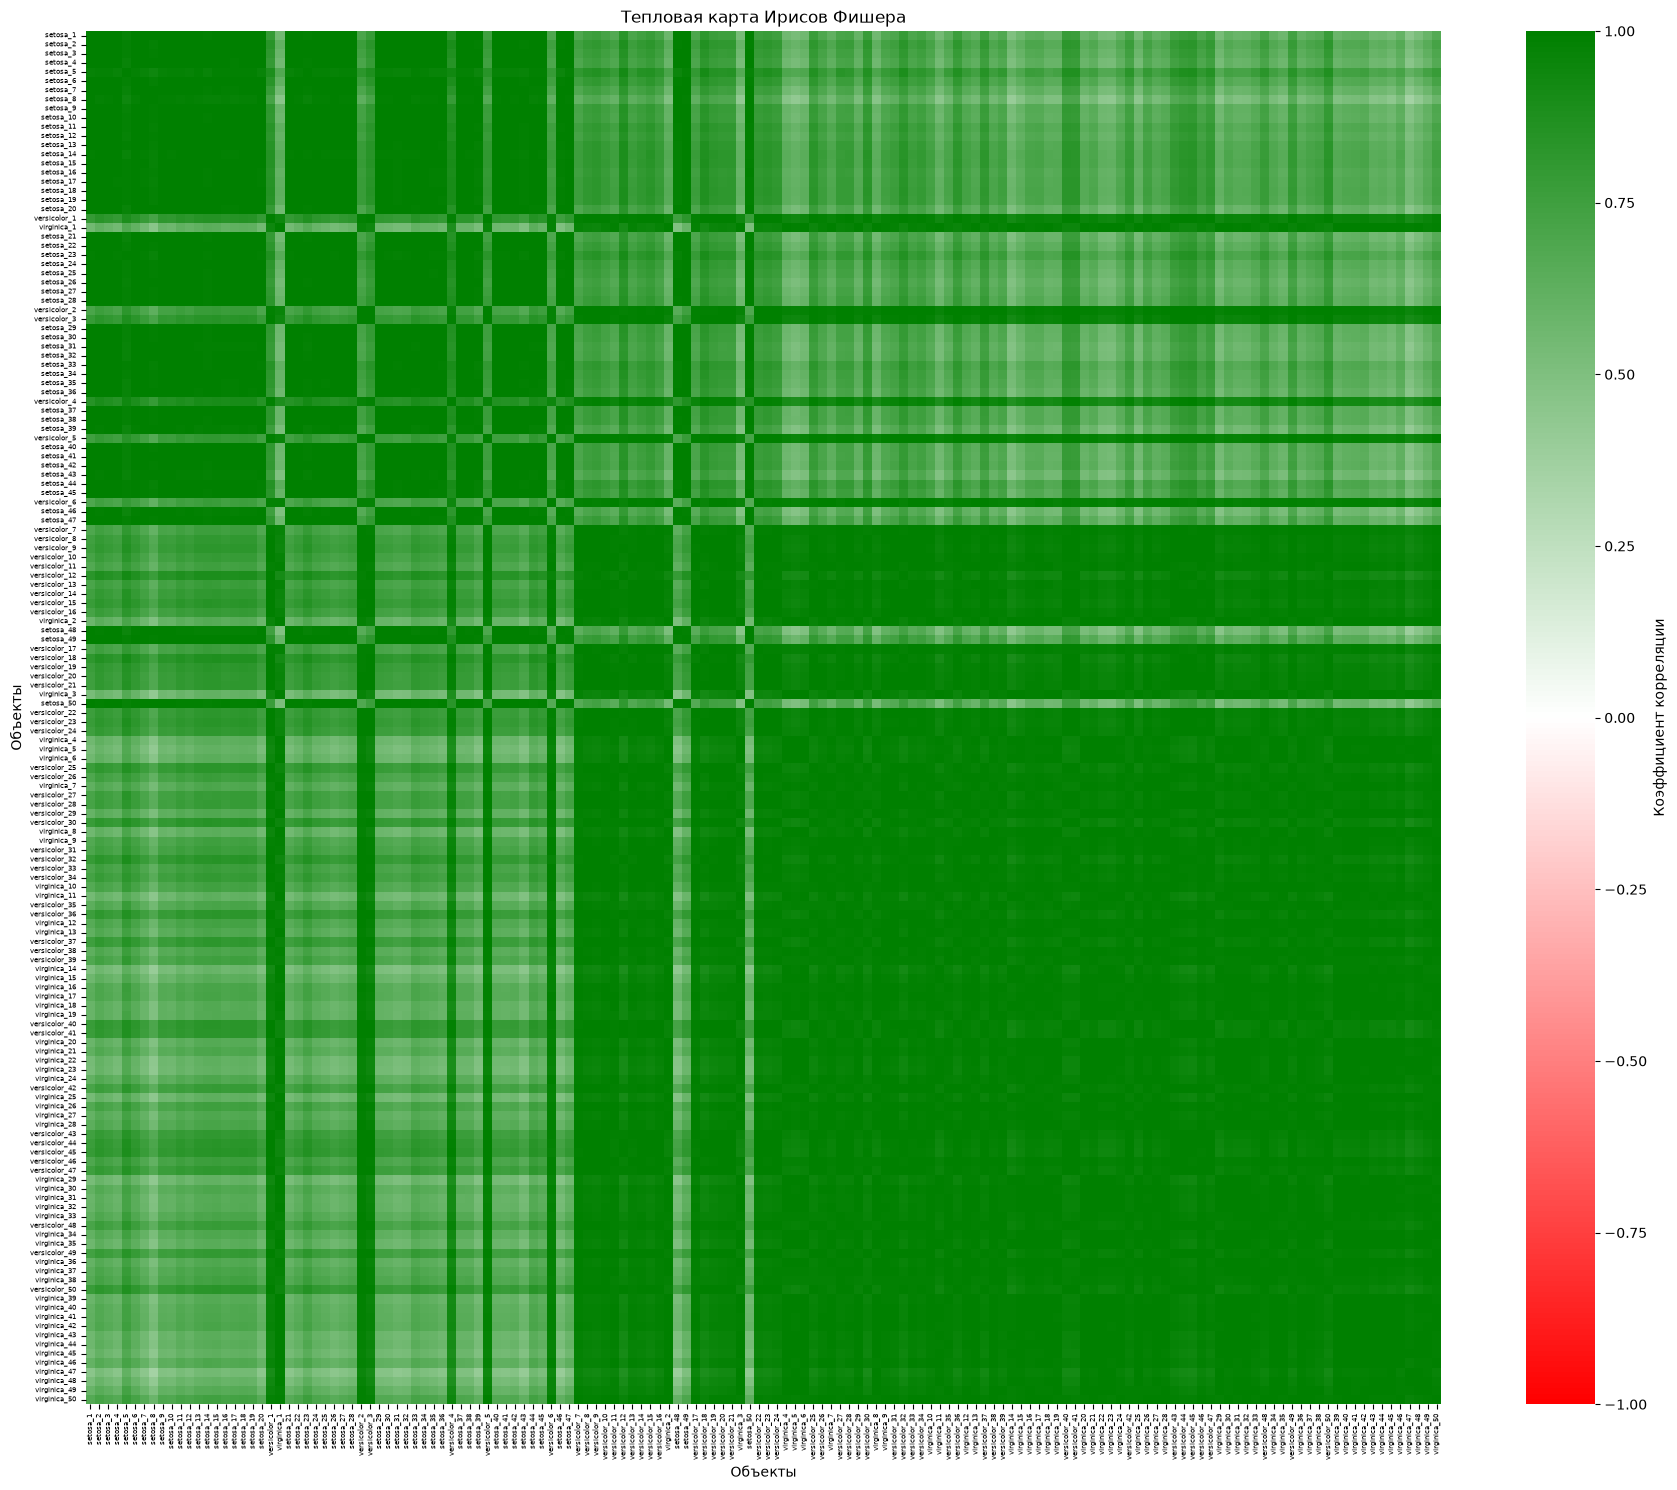

In [44]:
import seaborn as sns

fig, axes = plt.subplots(figsize=(18, 15))

sns.heatmap(
    correlation,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    xticklabels=names,
    yticklabels=names,
    cbar_kws={"label": "Коэффициент корреляции"},
    ax=axes,
)

axes.set_xticklabels(axes.get_xticklabels(), rotation=90, fontsize=5)

axes.set_yticklabels(axes.get_yticklabels(), rotation=0, fontsize=5)

axes.set_title("Тепловая карта Ирисов Фишера")
axes.set_xlabel("Объекты")
axes.set_ylabel("Объекты")

fig.tight_layout()

plt.show()
